In [6]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
import pandas as pd

from src.data_pipeline import get_prices
from src.Strategies import MovingAverageCrossover, MeanReversion
from src.Backtest import Backtester
from src.metrics import Metrics

In [2]:
def plot_equity_curves(results: dict[str, pd.DataFrame], title="Equity Curves"):
    """results: {label: equity_df} e.g. {'MA Crossover - AAPL': equity_df, ...}"""
    fig, ax = plt.subplots(figsize=(10, 5))
    for label, equity in results.items():
        ax.plot(pd.to_datetime(equity['date']), equity['value'], label=label)
    ax.set_title(title)
    ax.set_ylabel("Portfolio Value (normalized)")
    ax.legend()
    ax.grid(alpha=0.3)
    return fig

In [3]:
def plot_summary_comparison(summaries: list[dict]):
    """summaries: list of dicts from Metrics.summary()"""
    df = pd.DataFrame(summaries)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    df.plot.bar(x='strategy', y='sharpe_ratio', ax=axes[0], legend=False, title='Sharpe Ratio')
    df.plot.bar(x='strategy', y='max_drawdown', ax=axes[1], legend=False, title='Max Drawdown')
    df.plot.bar(x='strategy', y='win_rate', ax=axes[2], legend=False, title='Win Rate')
    plt.tight_layout()
    return fig

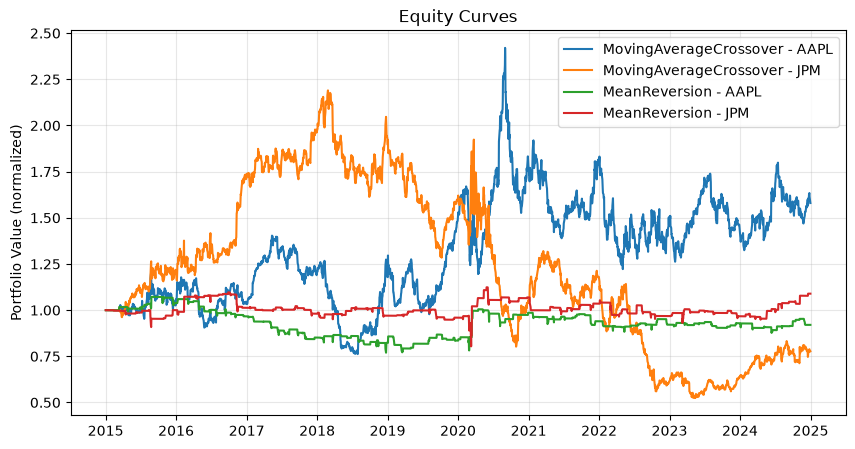

In [17]:
strategies = [MovingAverageCrossover(), MeanReversion()]
tickers = ['AAPL', 'JPM']

results = {}
for strat in strategies:
    for ticker in tickers:
        trades, equity = Backtester(strat).run(get_prices(ticker, db_path='../data/prices.db'))

        label = f"{strat.__class__.__name__} - {ticker}"
        results[label] = equity

fig = plot_equity_curves(results)
plt.show()